In [1]:
import re
import httpx
import os
from dotenv import load_dotenv
import anthropic

In [2]:
load_dotenv()
client = anthropic.Anthropic()

In [3]:
class Agent:
    def __init__(self,system=''):
        self.system = system
        self.messages = []
    
    def __call__(self,message):
        self.messages.append({'role':'user','content':message})
        result = self.execute()
        self.messages.append({'role':'assistant','content':result})
        return result
    
    def execute(self):
        response = client.messages.create(
            model='claude-haiku-4-5-20251001',
            system = self.system,
            max_tokens = 500,
            messages = self.messages,
            stop_sequences=["PAUSE"],
        )
        return response.content[0].text

In [4]:
system = '''
You run in a loop of Thought, Action, PAUSE, Observation.
At the end of the loop you output an Answer
Use Thought to describe your thoughts about the question you have been asked.
Use Action to run one of the actions available to you - then return PAUSE.
Observation will be the result of running those actions.

Your available actions are:

calc:
e.g. calc(4,7,'*')
Runs a calculation and returns the number - uses Python so be sure to use floating point syntax if necessary

search:
e.g. search('capital of france')
returns city name which is the capital of france

You are not permitted to answer using your own knowledge even if you are confident. Answer only using the tools provided
Example session:

Question: What is the capital of france?
Thought: I should look capital of france using search("capital of france")
Action: search('capital of france')
PAUSE

You will be called again with this:

Observation: Paris

You then output:

Answer: The capital of france is Paris
'''.strip()

In [5]:
def calc(a,b,op):
    match op:
        case '+':
            return a+b
        case '-':
            return a-b
        case '*':
            return a*b
        case '/':
            return a/b
        case _:
            return 'Unknown operator'

def search(s:str):
    search_data = {
        "capital of france": "Paris",
        "who wrote hamlet": "William Shakespeare",
        "tallest mountain": "Mount Everest",
        "speed of light": "About 299,792,458 meters per second",
        "population of japan": "About 123 million people",
        "largest ocean": "The Pacific Ocean",
        "inventor of the telephone": "Alexander Graham Bell",
        "boiling point of water": "100 degrees Celsius at sea level",
        "smallest planet": "Mercury",
        "author of 1984": "George Orwell",
    }
    if s.lower() in search_data:
        return search_data[s.lower()]
    else:
        return "not found"
    
known_actions = {
    'calc':calc,
    'search':search,
}

In [6]:
model = Agent(system)

In [7]:
result = model('what is the name of the startup that started on 25th august, 2017?')
print(result)

Thought: I need to search for information about a startup that was founded on August 25th, 2017. Let me search for this specific date.

Action: search('startup founded 25 august 2017')



In [8]:
action_re = re.compile(r'^Action: (\w+)\((.*)\)$')

In [9]:
def query(question, max_turns = 5):
    model = Agent(system)
    next_prompt = question
    for _ in range(max_turns):
        result = model(next_prompt)
        print(result)
        actions = [
            match for a in result.split('\n') if (match := action_re.match(a))
        ]
        if actions:
            action, action_args = actions[0].groups()
            if action not in known_actions:
                raise Exception(f'Unknown action: {action}')
            print(f'running {action} on {action_args}')
            if action == 'calc':
                action_args = action_args.replace(' ','').replace("'",'').split(',')
                observation = known_actions[action](int(action_args[0]),int(action_args[1]),action_args[2])
            else:
                observation = known_actions[action](action_args.replace("'",'').lower())
            print(f'Observation: {observation}')
            next_prompt = f'Observation: {observation}'
        else:
            return


In [10]:
question = "What's the boiling point of water? Add 50 to that number. Also, who is the inventor of the telephone?"
query(question)

Thought: I need to find the boiling point of water, add 50 to it, and find who invented the telephone. Let me start by searching for information about the boiling point of water and the inventor of the telephone.

Action: search('boiling point of water')

running search on 'boiling point of water'
Observation: 100 degrees Celsius at sea level
Thought: Great! The boiling point of water is 100 degrees Celsius. Now I need to add 50 to that number, and also search for the inventor of the telephone.

Action: calc(100, 50, '+')

running calc on 100, 50, '+'
Observation: 150
Thought: Good, I've calculated 100 + 50 = 150. Now I need to search for who invented the telephone.

Action: search('inventor of the telephone')

running search on 'inventor of the telephone'
Observation: Alexander Graham Bell
Answer: 
- The boiling point of water is 100 degrees Celsius at sea level
- Adding 50 to that number gives us: 150
- The inventor of the telephone is Alexander Graham Bell


# LangGraph Implementation

In [11]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_tavily import TavilySearch
from langchain_anthropic import ChatAnthropic

In [12]:
tool = TavilySearch(max_results=2)
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


In [13]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [22]:
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver.from_conn_string(':memory:')

In [25]:
class Agent:
    def __init__(self, model, tools, chec, system = ''):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node('llm',self.call_anthropic)
        graph.add_node('action',self.take_action)
        graph.add_conditional_edges(
            'llm',
            self.exists_action,
            {True:'action',False:END}, 
        )
        graph.add_edge('action','llm')
        graph.set_entry_point('llm')
        self.graph = graph.compile(checkpointer = chec)
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_anthropic(self, state:AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)]+messages
        message = self.model.invoke(messages)
        return {'messages':[message]}
    
    def take_action(self,state:AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f'calling {t}')
            if not t['name'] in self.tools:
                print("\n no such tool")
                result = "no such tool, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print('returned to model')
        return {'messages':results}

    def exists_action(self,state:AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

In [26]:
system = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""
bot = ChatAnthropic(model='claude-haiku-4-5-20251001')
model = Agent(bot,[tool], chec = memory, system=system)

TypeError: Invalid checkpointer provided. Expected an instance of `BaseCheckpointSaver`, `True`, `False`, or `None`. Received _GeneratorContextManager. Pass a proper saver (e.g., InMemorySaver, AsyncPostgresSaver).

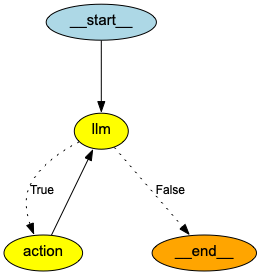

In [16]:
from IPython.display import Image
Image(model.graph.get_graph().draw_png())

In [19]:
messages = [HumanMessage(content="what is the weather in new brunswick nj?")]
result = model.graph.invoke({'messages':messages})

calling {'name': 'tavily_search', 'args': {'query': 'weather in New Brunswick NJ'}, 'id': 'toolu_01QddZpwUYJMWYWWXiZ7pK7a', 'type': 'tool_call'}
returned to model


In [20]:
result['messages'][-1].content

'I found a National Weather Service link for New Brunswick, NJ. However, the search results don\'t show the current weather details. The results indicate the forecast was last updated on August 11, 2026 at 4:09 PM EDT.\n\nTo get the current weather for New Brunswick, NJ, I\'d recommend visiting:\n- **National Weather Service**: https://forecast.weather.gov/MapClick.php?lon=-74.452&lat=40.486\n- **Weather Spark**: https://weatherspark.com/ (for detailed weather information)\n- Or try a quick search on Google for "New Brunswick NJ weather" for real-time conditions\n\nIf you\'d like, you can also tell me what specific weather information you\'re looking for (like temperature, precipitation, wind conditions, etc.) and I can try to find more current details for you!'

In [21]:
messages = [HumanMessage(content="what is the weather in new brunswick nj and also in sf?")]
result = model.graph.invoke({'messages':messages})

calling {'name': 'tavily_search', 'args': {'query': 'weather New Brunswick NJ'}, 'id': 'toolu_01K9jCUzxr3cJ3A5CC92XnNS', 'type': 'tool_call'}
calling {'name': 'tavily_search', 'args': {'query': 'weather San Francisco SF'}, 'id': 'toolu_011TMKtWXpHPRJnjTA5WMqwf', 'type': 'tool_call'}
returned to model
calling {'name': 'tavily_search', 'args': {'query': 'weather San Francisco California'}, 'id': 'toolu_01JcVTDk5eewwSr9vKE8weua', 'type': 'tool_call'}
returned to model
